In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.chdir(r'C:\Users\AnuragS\OneDrive\cv_project\Supply Chain Analysis\data')
os.getcwd()

'C:\\Users\\AnuragS\\OneDrive\\cv_project\\Supply Chain Analysis\\data'

In [3]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding="latin1")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.shape

(180519, 53)

In [5]:
df.columns = (df.columns
              .str.replace(' ','_')
              .str.replace('(','')
              .str.replace(')','')
              .str.lower().str.strip()
)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         180519 non-null  str    
 1   days_for_shipping_real       180519 non-null  int64  
 2   days_for_shipment_scheduled  180519 non-null  int64  
 3   benefit_per_order            180519 non-null  float64
 4   sales_per_customer           180519 non-null  float64
 5   delivery_status              180519 non-null  str    
 6   late_delivery_risk           180519 non-null  int64  
 7   category_id                  180519 non-null  int64  
 8   category_name                180519 non-null  str    
 9   customer_city                180519 non-null  str    
 10  customer_country             180519 non-null  str    
 11  customer_email               180519 non-null  str    
 12  customer_fname               180519 non-null  str    
 13  customer_i

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df_null = pd.DataFrame({
    'col_names': df.columns,
    'total_rows': df.shape[0],
    'null_rows':df.isnull().sum().values
})

df_null['null_pct'] = round((df_null['null_rows']/df_null['total_rows'])*100,4)

df_null = df_null.sort_values('null_rows',ascending=False)
df_null[df_null['null_rows'] != 0]

,col_names,total_rows,null_rows,null_pct
46,product_description,180519,180519,100.0000
43,order_zipcode,180519,155679,86.2397
14,customer_lname,180519,8,0.0044
19,customer_zipcode,180519,3,0.0017


For our analysis product description is not required

In [9]:
drop_cols = [
'benefit_per_order',
'customer_city',
'customer_email',
'customer_fname',
'customer_id',
'customer_lname',
'customer_password',
'customer_state',
'customer_street',
'customer_zipcode',
'department_id',
'latitude',
'longitude',
'market',
'order_city',
'order_country',
'order_customer_id',
'order_id',
'order_item_cardprod_id',
'order_item_discount',
'order_item_discount_rate',
'order_item_id',
'order_item_product_price',
'order_item_quantity',
'order_item_total',
'order_state',
'product_card_id',
'product_category_id',
'product_description',
'product_image',
'product_status',
'order_zipcode'                 
]

In [10]:
all_cols = list(df.columns)
req_col = [col for col in all_cols if col not in drop_cols]
req_col

['type',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_country',
 'customer_segment',
 'department_name',
 'order_date_dateorders',
 'order_item_profit_ratio',
 'sales',
 'order_profit_per_order',
 'order_region',
 'order_status',
 'product_name',
 'product_price',
 'shipping_date_dateorders',
 'shipping_mode']

In [11]:
df2 = df[req_col]
df2.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_country,customer_segment,...,order_date_dateorders,order_item_profit_ratio,sales,order_profit_per_order,order_region,order_status,product_name,product_price,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,314.640015,Advance shipping,0,73,Sporting Goods,Puerto Rico,Consumer,...,1/31/2018 22:56,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,73,Sporting Goods,Puerto Rico,Consumer,...,1/13/2018 12:27,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,73,Sporting Goods,EE. UU.,Consumer,...,1/13/2018 12:06,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,73,Sporting Goods,EE. UU.,Home Office,...,1/13/2018 11:45,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,73,Sporting Goods,Puerto Rico,Corporate,...,1/13/2018 11:24,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,1/15/2018 11:24,Standard Class


Need to filter out cancelled orders

In [12]:
df2['delivery_status'].value_counts(normalize=True)

delivery_status
Late delivery        0.548291
Advance shipping     0.230402
Shipping on time     0.178352
Shipping canceled    0.042954
Name: proportion, dtype: float64

In [13]:
df2 = df2[df2['delivery_status'] != 'Shipping canceled']
df2.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_country,customer_segment,...,order_date_dateorders,order_item_profit_ratio,sales,order_profit_per_order,order_region,order_status,product_name,product_price,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,314.640015,Advance shipping,0,73,Sporting Goods,Puerto Rico,Consumer,...,1/31/2018 22:56,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,73,Sporting Goods,Puerto Rico,Consumer,...,1/13/2018 12:27,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,73,Sporting Goods,EE. UU.,Consumer,...,1/13/2018 12:06,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,73,Sporting Goods,EE. UU.,Home Office,...,1/13/2018 11:45,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,73,Sporting Goods,Puerto Rico,Corporate,...,1/13/2018 11:24,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,1/15/2018 11:24,Standard Class


In [14]:
df2.info()

<class 'pandas.DataFrame'>
Index: 172765 entries, 0 to 180518
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         172765 non-null  str    
 1   days_for_shipping_real       172765 non-null  int64  
 2   days_for_shipment_scheduled  172765 non-null  int64  
 3   sales_per_customer           172765 non-null  float64
 4   delivery_status              172765 non-null  str    
 5   late_delivery_risk           172765 non-null  int64  
 6   category_id                  172765 non-null  int64  
 7   category_name                172765 non-null  str    
 8   customer_country             172765 non-null  str    
 9   customer_segment             172765 non-null  str    
 10  department_name              172765 non-null  str    
 11  order_date_dateorders        172765 non-null  str    
 12  order_item_profit_ratio      172765 non-null  float64
 13  sales          

In [15]:
date_cols = [col for col in df2.columns if 'date' in col]
date_cols

['order_date_dateorders', 'shipping_date_dateorders']

In [16]:
df2['order_date_dateorders'] = pd.to_datetime(df2['order_date_dateorders'])
df2['shipping_date_dateorders'] = pd.to_datetime(df2['shipping_date_dateorders'])

In [17]:
df2.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_country,customer_segment,...,order_date_dateorders,order_item_profit_ratio,sales,order_profit_per_order,order_region,order_status,product_name,product_price,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,314.640015,Advance shipping,0,73,Sporting Goods,Puerto Rico,Consumer,...,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,73,Sporting Goods,Puerto Rico,Consumer,...,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,73,Sporting Goods,EE. UU.,Consumer,...,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,73,Sporting Goods,EE. UU.,Home Office,...,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,73,Sporting Goods,Puerto Rico,Corporate,...,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [18]:
df2.shape

(172765, 21)

In [19]:
df2.isnull().sum()

type                           0
days_for_shipping_real         0
days_for_shipment_scheduled    0
sales_per_customer             0
delivery_status                0
late_delivery_risk             0
category_id                    0
category_name                  0
customer_country               0
customer_segment               0
department_name                0
order_date_dateorders          0
order_item_profit_ratio        0
sales                          0
order_profit_per_order         0
order_region                   0
order_status                   0
product_name                   0
product_price                  0
shipping_date_dateorders       0
shipping_mode                  0
dtype: int64

In [20]:
##cat_cols = list(df2.select_dtypes(include='str').columns)
for col in df2.columns:
    if df2[col].nunique() < 10:
        print(f'---{col}---')
        print(f'No. of Unique values = {df2[col].nunique()}')
        print(df2[col].value_counts())
        print(' ')

---type---
No. of Unique values = 4
type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64
 
---days_for_shipping_real---
No. of Unique values = 7
days_for_shipping_real
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64
 
---days_for_shipment_scheduled---
No. of Unique values = 4
days_for_shipment_scheduled
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64
 
---delivery_status---
No. of Unique values = 3
delivery_status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64
 
---late_delivery_risk---
No. of Unique values = 2
late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64
 
---customer_country---
No. of Unique values = 2
customer_country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64
 
---customer_segment---
No. of Unique values = 3
customer_segment
Consumer       89420
Cor

In [21]:
df2['order_precessing_time'] = (df2['shipping_date_dateorders'] - df2['order_date_dateorders']).dt.days 

df2['delay'] = df2['order_precessing_time'] -df2['days_for_shipment_scheduled']

df2['is_delayed'] = np.where(df2['delay'] > 0,1,0)

df2['order_day'] = df2['order_date_dateorders'].dt.day_name()
df2['order_month'] = df2['order_date_dateorders'].dt.month 
df2['order_hour'] = df2['order_date_dateorders'].dt.hour

In [22]:
df2.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_country,customer_segment,...,product_name,product_price,shipping_date_dateorders,shipping_mode,order_precessing_time,delay,is_delayed,order_day,order_month,order_hour
0,DEBIT,3,4,314.640015,Advance shipping,0,73,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,3,-1,0,Wednesday,1,22
1,TRANSFER,5,4,311.359985,Late delivery,1,73,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,5,1,1,Saturday,1,12
2,CASH,4,4,309.720001,Shipping on time,0,73,Sporting Goods,EE. UU.,Consumer,...,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,4,0,0,Saturday,1,12
3,DEBIT,3,4,304.809998,Advance shipping,0,73,Sporting Goods,EE. UU.,Home Office,...,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,3,-1,0,Saturday,1,11
4,PAYMENT,2,4,298.250000,Advance shipping,0,73,Sporting Goods,Puerto Rico,Corporate,...,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2,-2,0,Saturday,1,11


In [23]:
df2.describe().T

,count,mean,min,25%,50%,75%,max,std
days_for_shipping_real,172765.0,3.498596,0.0,2.0,3.0,5.0,6.0,1.623446
days_for_shipment_scheduled,172765.0,2.9331,0.0,2.0,4.0,4.0,4.0,1.373405
sales_per_customer,172765.0,183.165948,7.49,104.379997,163.990005,247.399994,1939.98999,120.141871
late_delivery_risk,172765.0,0.5729,0.0,0.0,1.0,1.0,1.0,0.494659
category_id,172765.0,31.856065,2.0,18.0,29.0,45.0,76.0,15.642216
order_date_dateorders,172765,2016-06-12 15:25:39.457991,2015-01-01 00:00:00,2015-09-21 18:01:00,2016-06-11 08:11:00,2017-02-28 21:08:00,2018-01-31 23:38:00,NaN
order_item_profit_ratio,172765.0,0.120801,-2.75,0.08,0.27,0.36,0.5,0.46661
sales,172765.0,203.828493,9.99,119.980003,199.919998,299.950012,1999.98999,132.39252
order_profit_per_order,172765.0,22.03236,-4274.97998,7.03,31.52,64.800003,911.799988,104.355313
product_price,172765.0,141.278595,9.99,50.0,59.990002,199.990005,1999.98999,139.862956


In [24]:
df2.is_delayed.value_counts()

is_delayed
1    94523
0    78242
Name: count, dtype: int64

In [25]:
df2.late_delivery_risk.value_counts()

late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [26]:
df2['profit_tag'] = np.where(
    df2['order_profit_per_order'] > 0,'Profit',
    np.where(df2['order_profit_per_order'] < 0,'Loss','Break Even'))

In [27]:
df2['profit_tag'].value_counts(normalize=True).index

Index(['Profit', 'Loss', 'Break Even'], dtype='str', name='profit_tag')

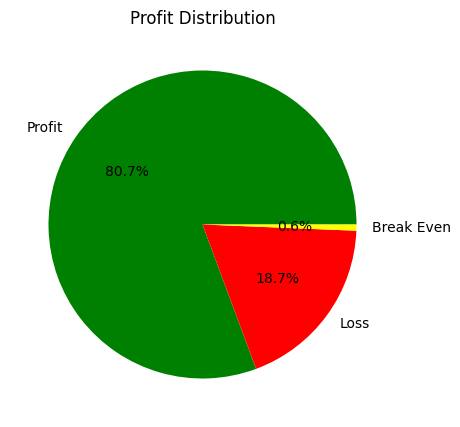

In [28]:
profit_cnt = df2['profit_tag'].value_counts(normalize=True)

color_map = {
    'Profit': 'green',
    'Loss': 'red',
    'Break Even': 'yellow'
}

colors = [color_map[label] for label in profit_cnt.index]



plt.figure(figsize=(5,5))
plt.pie(df2['profit_tag'].value_counts(normalize=True),
        labels= profit_cnt.index,
        autopct='%1.1f%%',
        colors=colors
        )
plt.title('Profit Distribution')
plt.show()

### Business KPIs

In [59]:
kpis = {}

# Total Orders
kpis['Total Orders'] = len(df2)

# Delayed orders
kpis['Delayed Orders'] = len(df2[df2['is_delayed'] == 1])

## ontime delivery
kpis['On time delivery'] = kpis['Total Orders'] - kpis['Delayed Orders']

# 90% of delayed orders were delivered within X days of the expected delivery date
kpis['90% Delay Days'] = int(df2[df2['is_delayed'] == 1]['delay'].quantile(0.9))

# On time delivery %
kpis['ontime delivery %'] = round((kpis['On time delivery']/kpis['Total Orders'])*100,2)

# Late Delivery % 
kpis['Late Delivery %'] = round((kpis['Delayed Orders']/kpis['Total Orders'])*100,2)

## Total profit
kpis['Total profit'] = float(round(df2.loc[df2['order_profit_per_order'] > 0, 'order_profit_per_order'].sum(),2))

## total loss due to delay
kpis['Total loss due to delay'] = float(round(df2.loc[df2['delay'] > 0, 'order_profit_per_order'].sum(),2))

In [45]:
round((kpis['Delayed Orders']/kpis['Total Orders'])*100,2)

54.71

In [60]:
kpis

{'Total Orders': 172765,
 'Delayed Orders': 94523,
 'On time delivery': 78242,
 '90% Delay Days': 3,
 'ontime delivery %': 45.29,
 'Late Delivery %': 54.71,
 'Total profit': 7514813.81,
 'Total loss due to delay': 2055765.16}

In [62]:
df_delay_analysis = df2[['delay','order_profit_per_order']]

In [64]:
df_delay_analysis['delay_check'] = np.where(
    df_delay_analysis['delay'] < 0,df2.order_profit_per_order,0
)

In [65]:
df_delay_analysis.head()

,delay,order_profit_per_order,delay_check
0,-1,91.250000,91.250000
1,1,-249.089996,0.000000
2,0,-247.779999,0.000000
3,-1,22.860001,22.860001
4,-2,134.210007,134.210007
